# Chapter 1B (Improved)

## Model Training — RF vs XGBoost vs LightGBM

### Improvements applied

- Compare **Random Forest vs XGBoost vs LightGBM** side-by-side
- `gap=5` in TimeSeriesSplit (was 1 — now matches 5-day rolling window)
- Probability calibration with `CalibratedClassifierCV`
- **Walk-forward (rolling) validation** — simulates real deployment
- **Trading simulation + Sharpe Ratio** — measures actual P&L, not just AUC


### Part A: Imports & Data Loading


In [ ]:
# A1. Import all libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (RandomizedSearchCV, TimeSeriesSplit, cross_val_score)
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, classification_report,
                              precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb

print("All imports successful!")
print(f"XGBoost  version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")


All imports successful!
XGBoost  version: 3.2.0
LightGBM version: 4.6.0


In [ ]:
# A2. Load improved dataset (v2)
dataset_file = "./final-processed-ML-training-data.csv"

data = pd.read_csv(dataset_file, index_col="date")
data.index = pd.to_datetime(data.index)

print(f"Dataset shape : {data.shape}")
print(f"Date range    : {data.index[0].date()} → {data.index[-1].date()}")
data.head(2)


Dataset shape : (3553, 33)
Date range    : 2011-01-28 → 2025-03-14


,open,high,low,close,adj_close,volume,ma20,ma_cross,return,volume_change,...,stoch_k,return_5d,return_20d,vol_regime,rsi14_lag1,bb_width_lag1,day_of_week,month,quarter,atr14_pct
date,,,,,,,,,,,,,,,,,,,,,
2011-01-28,12.291786,12.300000,11.911786,12.003571,10.114455,592057200,10.157854,1,-0.020716,0.731023,...,-189.359377,0.028709,0.038435,0.014402,58.479278,0.088431,4,1,1,0.079801
2011-01-31,11.992857,12.144286,11.939286,12.118571,10.211362,377246800,10.183072,1,0.009581,0.000000,...,-177.353247,0.005542,0.051960,0.014439,49.983376,0.080247,0,1,1,0.079044


### Part B: Train / Test Split & Scaling


In [ ]:
# B1. Separate features and target
feature_cols = [col for col in data.columns if col != 'target']
X = data[feature_cols]
y = data['target']

print(f"Features : {X.shape}")
print(f"Target   : {y.shape}")
print(f"\nFeature list ({len(feature_cols)} features):")
for f in feature_cols:
    print(f"  {f}")


Features : (3553, 32)
Target   : (3553,)

Feature list (32 features):
  open
  high
  low
  close
  adj_close
  volume
  ma20
  ma_cross
  return
  volume_change
  rsi14
  bb_width
  signal
  return_lag1
  return_lag3
  52w_high_ratio
  52w_low_ratio
  ma20_ratio
  roc5
  roc10
  obv
  obv_ratio
  stoch_k
  return_5d
  return_20d
  vol_regime
  rsi14_lag1
  bb_width_lag1
  day_of_week
  month
  quarter
  atr14_pct


In [ ]:
# B2. Temporal 80/20 split — NO random shuffle on time series
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {X_train.shape}  →  {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"Test  : {X_test.shape}   →  {X_test.index[0].date()} to {X_test.index[-1].date()}")


Train : (2842, 32)  →  2011-01-28 to 2022-05-12
Test  : (711, 32)   →  2022-05-13 to 2025-03-14


In [ ]:
# B3. RobustScaler — fit ONLY on train, then transform both
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols, index=X_test.index
)

print("Scaling complete!")
print(f"  Train scaled : {X_train_scaled.shape}")
print(f"  Test scaled  : {X_test_scaled.shape}")


Scaling complete!
  Train scaled : (2842, 32)
  Test scaled  : (711, 32)


### Part C: Data Leakage Demo


           LEAKAGE DEMO
  Random Split AUC-ROC     : 0.5236  ← FAKE (data leakage)
  TimeSeriesSplit AUC-ROC  : 0.4997  ← REAL (honest)
  gap=5 (was gap=1) ensures 5-day features don't bleed across folds


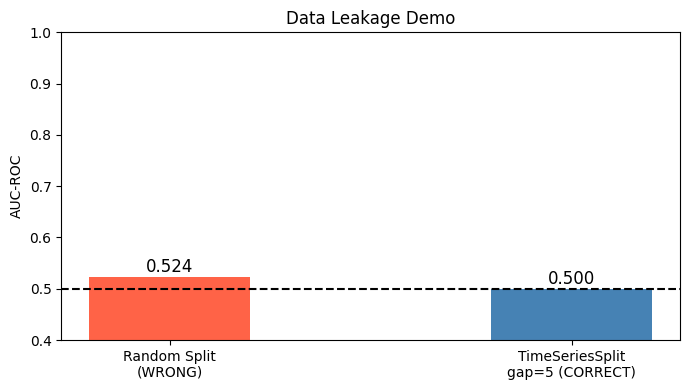

In [ ]:
# C1. Leakage demo — random split vs TimeSeriesSplit (gap=5)
from sklearn.model_selection import train_test_split

# Wrong: random split
X_rand_train, X_rand_test, y_rand_train, y_rand_test = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)
rf_leak = RandomForestClassifier(n_estimators=100, random_state=42)
rf_leak.fit(X_rand_train, y_rand_train)
leak_auc = roc_auc_score(y_rand_test, rf_leak.predict_proba(X_rand_test)[:,1])

# Correct: TimeSeriesSplit with gap=5
# gap=5 matches the 5-day rolling window in our features — prevents leakage
tscv = TimeSeriesSplit(n_splits=5, gap=5)
rf_honest = RandomForestClassifier(n_estimators=100, random_state=42)
honest_scores = cross_val_score(rf_honest, X_train_scaled, y_train,
                                 cv=tscv, scoring='roc_auc')
honest_auc = honest_scores.mean()

print("=" * 50)
print("           LEAKAGE DEMO")
print("=" * 50)
print(f"  Random Split AUC-ROC     : {leak_auc:.4f}  ← FAKE (data leakage)")
print(f"  TimeSeriesSplit AUC-ROC  : {honest_auc:.4f}  ← REAL (honest)")
print(f"  gap=5 (was gap=1) ensures 5-day features don't bleed across folds")
print("=" * 50)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Random Split\n(WRONG)', 'TimeSeriesSplit\ngap=5 (CORRECT)'],
              [leak_auc, honest_auc],
              color=['tomato', 'steelblue'], width=0.4)
ax.axhline(y=0.5, color='black', linestyle='--', label='Random baseline')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('AUC-ROC')
ax.set_title('Data Leakage Demo')
for bar, val in zip(bars, [leak_auc, honest_auc]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("1B: leakage_demo.png", dpi=300, bbox_inches="tight")
plt.show()


### Part D: Hyperparameter Tuning — All Three Models


In [ ]:
# D1. Random Forest — RandomizedSearchCV + TimeSeriesSplit(gap=5)
tscv = TimeSeriesSplit(n_splits=5, gap=5)

rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [3, 5, 7, 9, 11, 13, 15, None],
    'min_samples_leaf' : [1, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=50, scoring='roc_auc',
    cv=tscv, random_state=42, verbose=1, n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)

print("\n" + "=" * 50)
print("  RF BEST PARAMS")
print("=" * 50)
for k, v in rf_search.best_params_.items():
    print(f"  {k:25s}: {v}")
print(f"\n  Best CV AUC-ROC : {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

  RF BEST PARAMS
  n_estimators             : 500
  min_samples_split        : 2
  min_samples_leaf         : 1
  max_features             : log2
  max_depth                : 5
  class_weight             : balanced

  Best CV AUC-ROC : 0.5257


In [ ]:
# D2. XGBoost — RandomizedSearchCV + TimeSeriesSplit(gap=5)
xgb_param_dist = {
    'n_estimators'  : [100, 200, 300, 400, 500],
    'learning_rate' : [0.01, 0.03, 0.05, 0.1, 0.15],
    'max_depth'     : [3, 4, 5, 6, 7],
    'subsample'     : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma'         : [0, 0.1, 0.3, 0.5],
    'scale_pos_weight': [1, 1.15]   # handles mild class imbalance
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42,
                       use_label_encoder=False, n_jobs=-1),
    xgb_param_dist,
    n_iter=50, scoring='roc_auc',
    cv=tscv, random_state=42, verbose=1, n_jobs=-1
)
xgb_search.fit(X_train_scaled, y_train)

print("\n" + "=" * 50)
print("  XGBoost BEST PARAMS")
print("=" * 50)
for k, v in xgb_search.best_params_.items():
    print(f"  {k:25s}: {v}")
print(f"\n  Best CV AUC-ROC : {xgb_search.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

  XGBoost BEST PARAMS
  subsample                : 1.0
  scale_pos_weight         : 1.15
  n_estimators             : 200
  min_child_weight         : 10
  max_depth                : 6
  learning_rate            : 0.01
  gamma                    : 0
  colsample_bytree         : 0.6

  Best CV AUC-ROC : 0.5351


In [ ]:
# D3. LightGBM — RandomizedSearchCV + TimeSeriesSplit(gap=5)
lgb_param_dist = {
    'n_estimators'   : [100, 200, 300, 400, 500],
    'learning_rate'  : [0.01, 0.03, 0.05, 0.1, 0.15],
    'num_leaves'     : [15, 31, 50, 63, 100],
    'max_depth'      : [-1, 5, 7, 10, 15],
    'min_child_samples': [10, 20, 30, 50],
    'subsample'      : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'      : [0, 0.1, 0.5, 1.0],
    'reg_lambda'     : [0, 0.1, 0.5, 1.0],
    'class_weight'   : [None, 'balanced']
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    lgb_param_dist,
    n_iter=50, scoring='roc_auc',
    cv=tscv, random_state=42, verbose=1, n_jobs=-1
)
lgb_search.fit(X_train_scaled, y_train)

print("\n" + "=" * 50)
print("  LightGBM BEST PARAMS")
print("=" * 50)
for k, v in lgb_search.best_params_.items():
    print(f"  {k:25s}: {v}")
print(f"\n  Best CV AUC-ROC : {lgb_search.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

  LightGBM BEST PARAMS
  subsample                : 0.8
  reg_lambda               : 0.5
  reg_alpha                : 1.0
  num_leaves               : 50
  n_estimators             : 100
  min_child_samples        : 50
  max_depth                : -1
  learning_rate            : 0.05
  colsample_bytree         : 0.8
  class_weight             : None

  Best CV AUC-ROC : 0.5362


### Part E: Probability Calibration


In [ ]:
# E1. Calibrate probabilities — RF probabilities are poorly calibrated by default
# CalibratedClassifierCV wraps the model and corrects the probability outputs
# method='isotonic' works better than 'sigmoid' for larger datasets

best_rf_raw = rf_search.best_estimator_

calibrated_rf = CalibratedClassifierCV(best_rf_raw, method='isotonic', cv=3)
calibrated_rf.fit(X_train_scaled, y_train)

# Compare raw vs calibrated on test set
raw_proba        = best_rf_raw.predict_proba(X_test_scaled)[:,1]
calibrated_proba = calibrated_rf.predict_proba(X_test_scaled)[:,1]

auc_raw  = roc_auc_score(y_test, raw_proba)
auc_cal  = roc_auc_score(y_test, calibrated_proba)

print(f"RF Raw AUC-ROC       : {auc_raw:.4f}")
print(f"RF Calibrated AUC-ROC: {auc_cal:.4f}")
print("Using calibrated model going forward." if auc_cal >= auc_raw
      else "Raw model performed better — keeping raw.")

best_rf_model   = calibrated_rf if auc_cal >= auc_raw else best_rf_raw
rf_proba_final  = calibrated_proba if auc_cal >= auc_raw else raw_proba


RF Raw AUC-ROC       : 0.4921
RF Calibrated AUC-ROC: 0.4891
Raw model performed better — keeping raw.


### Part F: Model Comparison — RF vs XGBoost vs LightGBM


In [ ]:
# F1. Get predictions from all three models on held-out test set
xgb_proba = xgb_search.best_estimator_.predict_proba(X_test_scaled)[:,1]
lgb_proba = lgb_search.best_estimator_.predict_proba(X_test_scaled)[:,1]

results = {}

for name, proba in [('Random Forest', rf_proba_final),
                    ('XGBoost',       xgb_proba),
                    ('LightGBM',      lgb_proba)]:
    auc  = roc_auc_score(y_test, proba)
    pred = (proba >= 0.5).astype(int)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    results[name] = {'AUC-ROC': auc, 'Precision': prec,
                     'Recall': rec, 'F1': f1, 'proba': proba}

print("=" * 60)
print(f"{'Model':<18} {'AUC-ROC':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 60)
for name, m in results.items():
    print(f"{name:<18} {m['AUC-ROC']:>9.4f} {m['Precision']:>10.4f}"
          f" {m['Recall']:>8.4f} {m['F1']:>8.4f}")
print("=" * 60)

# Pick the best model by AUC-ROC
best_model_name = max(results, key=lambda k: results[k]['AUC-ROC'])
best_proba      = results[best_model_name]['proba']
print(f"\n→ Best model: {best_model_name} (AUC {results[best_model_name]['AUC-ROC']:.4f})")


Model                AUC-ROC  Precision   Recall       F1
------------------------------------------------------------
Random Forest         0.4921     0.5041   0.1636   0.2470
XGBoost               0.4833     0.5332   0.5515   0.5422
LightGBM              0.4793     0.5281   0.3219   0.4000

→ Best model: Random Forest (AUC 0.4921)


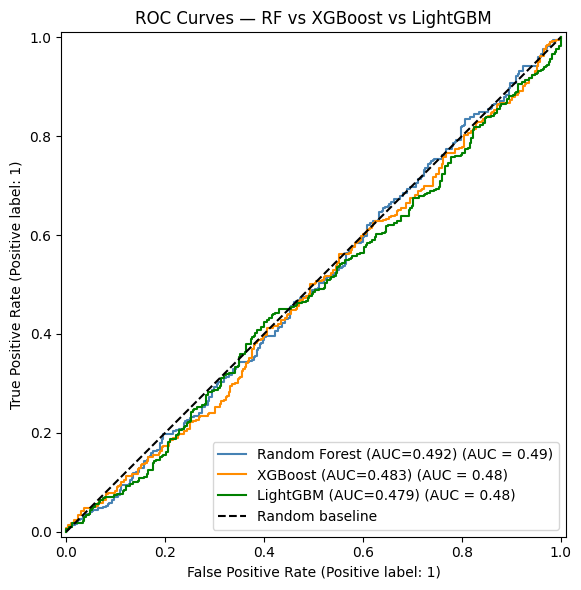

In [ ]:
# F2. ROC Curves — all three on one chart
fig, ax = plt.subplots(figsize=(9, 6))

colors = {'Random Forest': 'steelblue', 'XGBoost': 'darkorange', 'LightGBM': 'green'}
for name, m in results.items():
    RocCurveDisplay.from_predictions(
        y_test, m['proba'],
        ax=ax, color=colors[name],
        name=f"{name} (AUC={m['AUC-ROC']:.3f})"
    )

ax.plot([0,1],[0,1],'k--', label='Random baseline')
ax.set_title('ROC Curves — RF vs XGBoost vs LightGBM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("1B: roc_curves_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Part G: Threshold Tuning on Best Model


Default threshold (0.50) → Precision: 0.5041
Optimal threshold (0.32) → Precision: 0.5355

Threshold sweep:
 Threshold  Precision     Recall         F1
---------------------------------------------
      0.40     0.5264     0.5264     0.5264
      0.45     0.5233     0.5233     0.5233
      0.50     0.5041     0.5041     0.5041
      0.55     0.4667     0.4667     0.4667
      0.60     0.0000     0.0000     0.0000
      0.65     0.0000     0.0000     0.0000
      0.70     0.0000     0.0000     0.0000


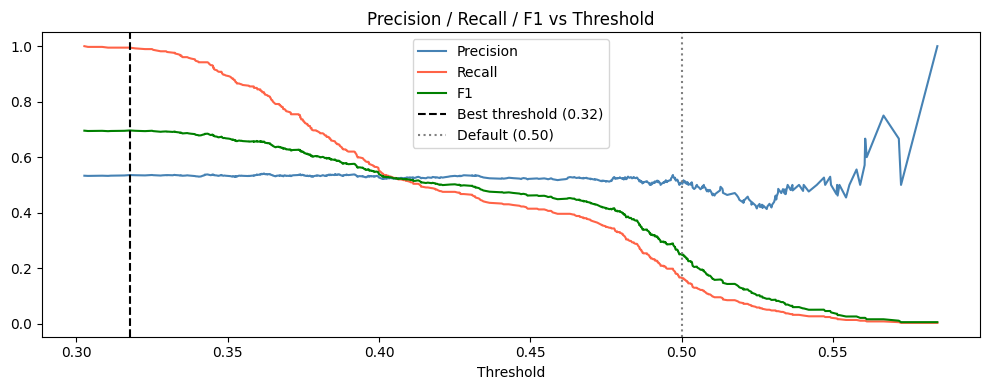

In [ ]:
# G1. Find optimal decision threshold for best model
precisions, recalls, thresholds = precision_recall_curve(y_test, best_proba)

f1_scores   = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"Default threshold (0.50) → Precision: "
      f"{precision_score(y_test, (best_proba >= 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}) → Precision: "
      f"{precision_score(y_test, (best_proba >= best_thresh).astype(int)):.4f}")

print(f"\nThreshold sweep:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)
for t in np.arange(0.40, 0.71, 0.05):
    preds_t = (best_proba >= t).astype(int)
    p = precision_score(y_test, preds_t, zero_division=0)
    r = y_test[preds_t == 1].mean() if preds_t.sum() > 0 else 0
    f = 2*p*r/(p+r+1e-8)
    marker = " ← optimal" if abs(t - best_thresh) < 0.025 else ""
    print(f"{t:>10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f}{marker}")

# Precision/Recall/F1 vs threshold chart
plt.figure(figsize=(10, 4))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='tomato')
plt.plot(thresholds, f1_scores[:-1],  label='F1',        color='green')
plt.axvline(x=best_thresh, color='black', linestyle='--',
            label=f'Best threshold ({best_thresh:.2f})')
plt.axvline(x=0.50, color='gray', linestyle=':', label='Default (0.50)')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.savefig("1B: threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

y_pred_final = (best_proba >= best_thresh).astype(int)


### Part H: Final Evaluation of Best Model


     FINAL EVALUATION — Random Forest
  AUC-ROC   : 0.4921
  Precision : 0.5355
  Recall    : 0.9947
  F1 Score  : 0.6962
  Threshold : 0.32

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.71      0.02      0.03       332
          UP       0.54      0.99      0.70       379

    accuracy                           0.54       711
   macro avg       0.62      0.50      0.36       711
weighted avg       0.62      0.54      0.38       711



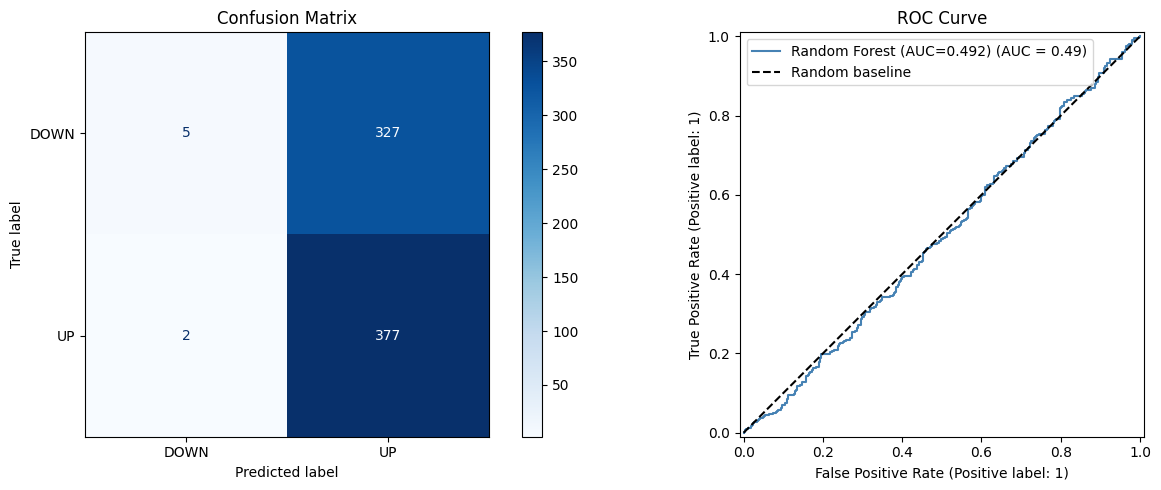

In [ ]:
# H1. Full classification report + confusion matrix
auc  = roc_auc_score(y_test, best_proba)
prec = precision_score(y_test, y_pred_final, zero_division=0)
rec  = recall_score(y_test, y_pred_final, zero_division=0)
f1   = f1_score(y_test, y_pred_final, zero_division=0)

print("=" * 50)
print(f"     FINAL EVALUATION — {best_model_name}")
print("=" * 50)
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Threshold : {best_thresh:.2f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['DOWN','UP']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['DOWN','UP'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(
    y_test, best_proba,
    ax=axes[1], color='steelblue',
    name=f'{best_model_name} (AUC={auc:.3f})'
)
axes[1].plot([0,1],[0,1],'k--', label='Random baseline')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig("1B: confusion_matrix_and_roc.png", dpi=300, bbox_inches="tight")
plt.show()


### Part I: Feature Importance (Best Model)


Feature Importances:
       feature  importance
   return_lag3      0.0547
        return      0.0529
          roc5      0.0473
     return_5d      0.0461
           obv      0.0446
   return_lag1      0.0426
    ma20_ratio      0.0393
    return_20d      0.0393
   day_of_week      0.0387
      bb_width      0.0376
         roc10      0.0362
     atr14_pct      0.0350
     obv_ratio      0.0324
 bb_width_lag1      0.0319
          open      0.0304
       stoch_k      0.0299
         rsi14      0.0299
        volume      0.0291
    rsi14_lag1      0.0290
    vol_regime      0.0289
 52w_low_ratio      0.0281
          high      0.0268
          ma20      0.0261
52w_high_ratio      0.0260
        signal      0.0254
         close      0.0243
           low      0.0240
     adj_close      0.0239
 volume_change      0.0224
         month      0.0116
       quarter      0.0047
      ma_cross      0.0008

Features below 1% importance (drop candidates): ['quarter', 'ma_cross']


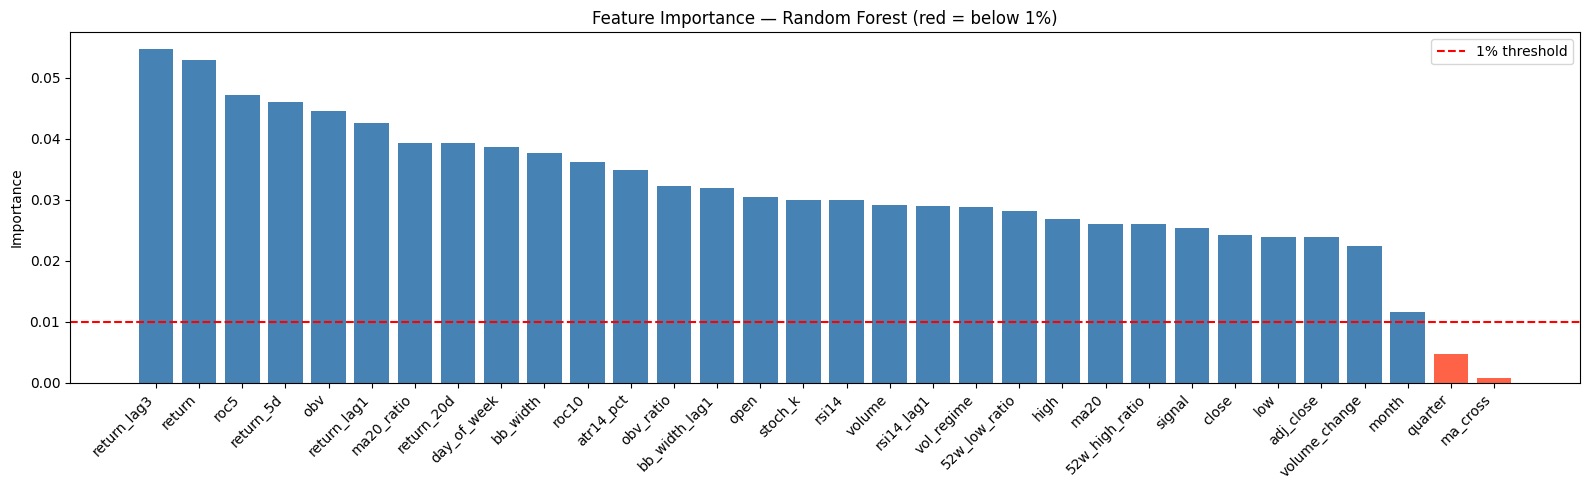

In [ ]:
# I1. Feature importances from best model
# For RF: .feature_importances_ directly
# For XGB/LGB: same attribute on .best_estimator_

model_map = {
    'Random Forest': rf_search.best_estimator_,
    'XGBoost':       xgb_search.best_estimator_,
    'LightGBM':      lgb_search.best_estimator_
}
chosen_estimator = model_map[best_model_name]

importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': chosen_estimator.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Feature Importances:")
print(importance_df.round(4).to_string(index=False))

weak_features = importance_df[importance_df['importance'] < 0.01]['feature'].tolist()
print(f"\nFeatures below 1% importance (drop candidates): {weak_features}")

colors_imp = ['tomato' if imp < 0.01 else 'steelblue'
              for imp in importance_df['importance']]
plt.figure(figsize=(16, 5))
plt.bar(importance_df['feature'], importance_df['importance'], color=colors_imp)
plt.axhline(y=0.01, color='red', linestyle='--', label='1% threshold')
plt.xticks(rotation=45, ha='right')
plt.title(f'Feature Importance — {best_model_name} (red = below 1%)')
plt.ylabel('Importance')
plt.legend()
plt.tight_layout()
plt.savefig("1B: feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


### Part J: Walk-Forward (Rolling) Validation


Walk-Forward Results (44 windows):
  Mean AUC : 0.5338
  Std  AUC : 0.0836
  Min  AUC : 0.3704
  Max  AUC : 0.6878


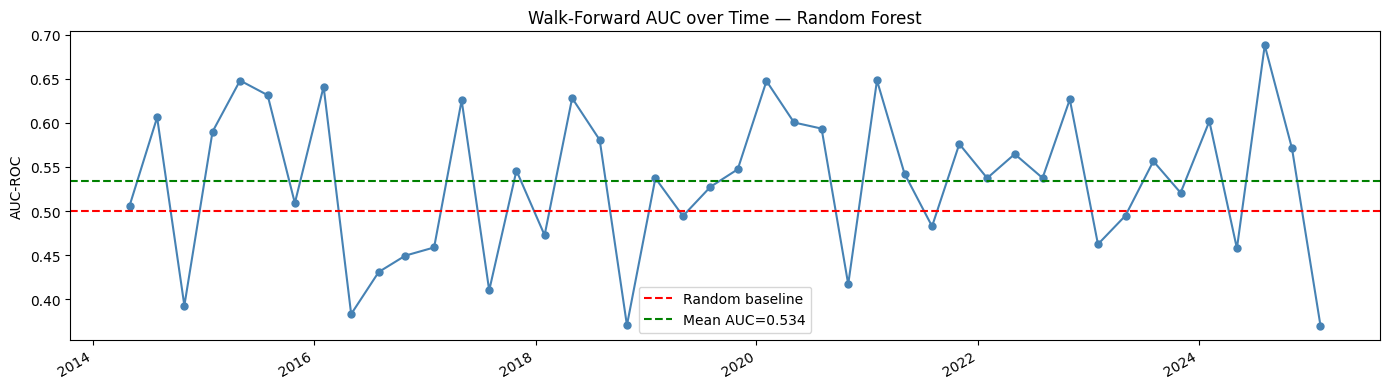

In [ ]:
# J1. Walk-forward simulation
# Retrain every 252 days (1 year), predict next 63 days (1 quarter)
# This mirrors real deployment: the model is periodically retrained as new data arrives

TRAIN_WINDOW = 252 * 3   # 3 years of training data
STEP         = 63         # predict 1 quarter at a time

wf_results   = []
wf_dates     = []

for start in range(0, len(X) - TRAIN_WINDOW - STEP, STEP):
    X_wf_train = X.iloc[start : start + TRAIN_WINDOW]
    y_wf_train = y.iloc[start : start + TRAIN_WINDOW]
    X_wf_test  = X.iloc[start + TRAIN_WINDOW : start + TRAIN_WINDOW + STEP]
    y_wf_test  = y.iloc[start + TRAIN_WINDOW : start + TRAIN_WINDOW + STEP]

    # Scale per-window (fit on train only)
    sc = RobustScaler()
    Xtr_sc = sc.fit_transform(X_wf_train)
    Xte_sc = sc.transform(X_wf_test)

    # Use best model type with best params
    if best_model_name == 'Random Forest':
        m = RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1)
    elif best_model_name == 'XGBoost':
        m = xgb.XGBClassifier(**xgb_search.best_params_, eval_metric='logloss',
                               use_label_encoder=False, random_state=42, n_jobs=-1)
    else:
        m = lgb.LGBMClassifier(**lgb_search.best_params_, random_state=42,
                                n_jobs=-1, verbose=-1)

    m.fit(Xtr_sc, y_wf_train)
    preds = m.predict_proba(Xte_sc)[:,1]

    if len(np.unique(y_wf_test)) == 2:
        auc_wf = roc_auc_score(y_wf_test, preds)
        wf_results.append(auc_wf)
        wf_dates.append(X_wf_test.index[-1])

wf_series = pd.Series(wf_results, index=wf_dates)

print(f"Walk-Forward Results ({len(wf_results)} windows):")
print(f"  Mean AUC : {np.mean(wf_results):.4f}")
print(f"  Std  AUC : {np.std(wf_results):.4f}")
print(f"  Min  AUC : {np.min(wf_results):.4f}")
print(f"  Max  AUC : {np.max(wf_results):.4f}")

# Plot
plt.figure(figsize=(14, 4))
wf_series.plot(color='steelblue', marker='o', markersize=5)
plt.axhline(y=0.5, color='red',  linestyle='--', label='Random baseline')
plt.axhline(y=np.mean(wf_results), color='green',
            linestyle='--', label=f'Mean AUC={np.mean(wf_results):.3f}')
plt.title(f'Walk-Forward AUC over Time — {best_model_name}')
plt.ylabel('AUC-ROC')
plt.legend()
plt.tight_layout()
plt.savefig("1B: walk_forward_auc.png", dpi=300, bbox_inches="tight")
plt.show()

## INTERPRETATION:
# Consistent AUC > 0.5 across all windows = model generalises over time.
# Declining trend = model decay — consider retraining more frequently.


### Part K: Trading Simulation & Sharpe Ratio


          TRADING SIMULATION RESULTS
  Total test days         : 711
  Days we traded (UP sig) : 704
  Win rate on trade days  : 53.1%
  Market total return     : 52.0%
  Strategy total return   : 43.9%
  Sharpe Ratio            : 0.62
  Max Drawdown            : -28.3%

Sharpe interpretation:
  < 0    : Strategy loses money
  0–1    : Positive but not great
  1–2    : Good
  > 2    : Excellent (rare in real markets)


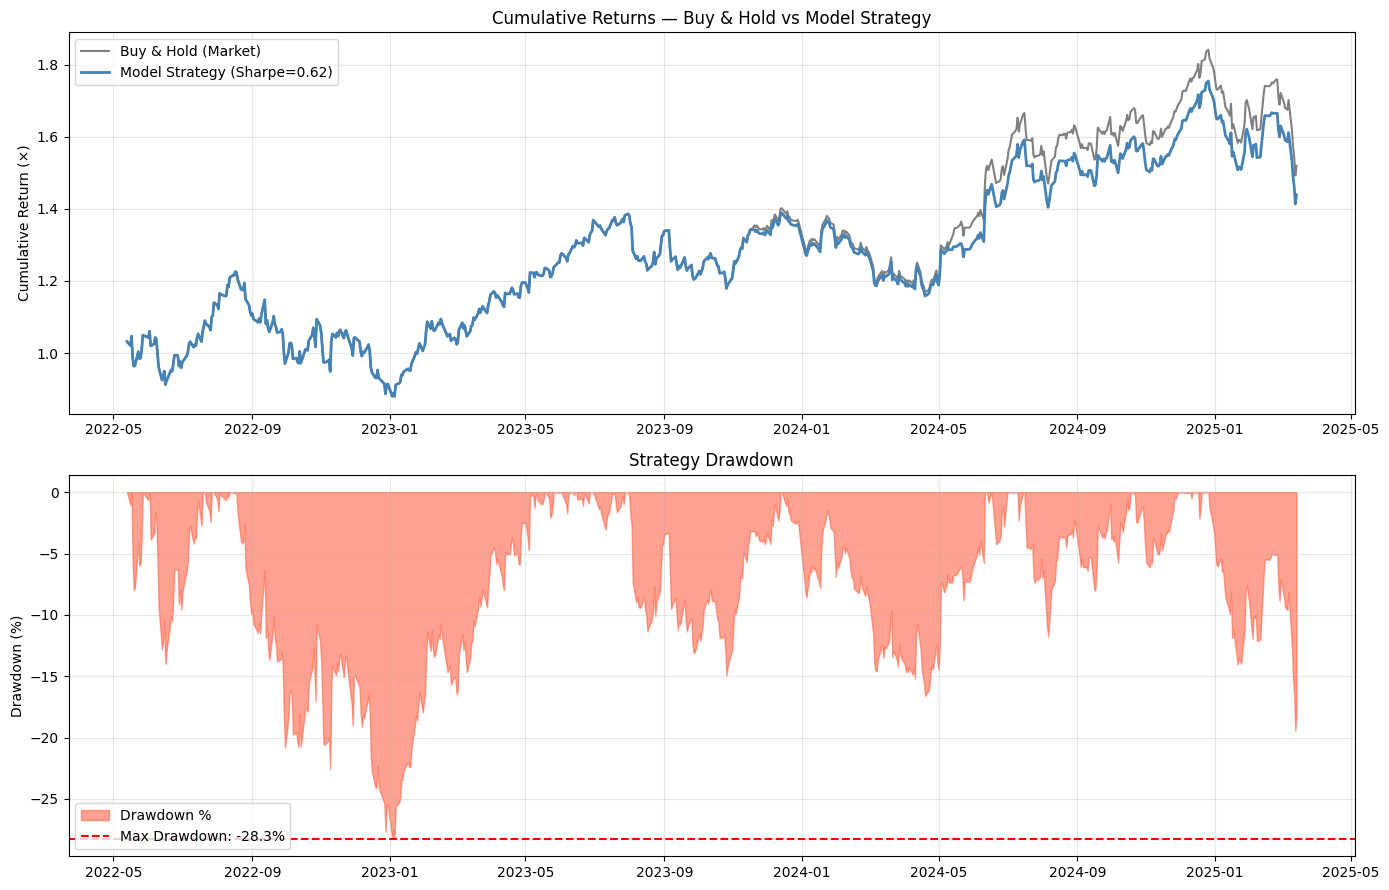

In [ ]:
# K1. Build a simple trading strategy from model signals
# Rule: Go LONG (buy) when model predicts UP, stay out when it predicts DOWN
# No short-selling — this is a directional long-only strategy

test_df = X_test.copy()
test_df['actual']          = y_test.values
test_df['predicted']       = y_pred_final
test_df['prob_up']         = best_proba
test_df['market_return']   = data.loc[X_test.index, 'return']

# Strategy return: only earn market return on days we predict UP
test_df['strategy_return'] = test_df['predicted'] * test_df['market_return']

# Cumulative returns
test_df['cum_market']   = (1 + test_df['market_return']).cumprod()
test_df['cum_strategy'] = (1 + test_df['strategy_return']).cumprod()

# Sharpe Ratio (annualised, risk-free rate = 0 for simplicity)
daily_mean = test_df['strategy_return'].mean()
daily_std  = test_df['strategy_return'].std()
sharpe     = (daily_mean / (daily_std + 1e-8)) * np.sqrt(252)

# Max Drawdown
rolling_max = test_df['cum_strategy'].cummax()
drawdown    = (test_df['cum_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Win rate
win_days  = (test_df['strategy_return'] > 0).sum()
trade_days = (test_df['predicted'] == 1).sum()
win_rate   = win_days / trade_days if trade_days > 0 else 0

print("=" * 55)
print("          TRADING SIMULATION RESULTS")
print("=" * 55)
print(f"  Total test days         : {len(test_df)}")
print(f"  Days we traded (UP sig) : {trade_days}")
print(f"  Win rate on trade days  : {win_rate*100:.1f}%")
print(f"  Market total return     : {(test_df['cum_market'].iloc[-1]-1)*100:.1f}%")
print(f"  Strategy total return   : {(test_df['cum_strategy'].iloc[-1]-1)*100:.1f}%")
print(f"  Sharpe Ratio            : {sharpe:.2f}")
print(f"  Max Drawdown            : {max_drawdown*100:.1f}%")
print("=" * 55)
print("\nSharpe interpretation:")
print("  < 0    : Strategy loses money")
print("  0–1    : Positive but not great")
print("  1–2    : Good")
print("  > 2    : Excellent (rare in real markets)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Cumulative returns
axes[0].plot(test_df.index, test_df['cum_market'],
             label='Buy & Hold (Market)', color='gray', linewidth=1.5)
axes[0].plot(test_df.index, test_df['cum_strategy'],
             label=f'Model Strategy (Sharpe={sharpe:.2f})',
             color='steelblue', linewidth=2)
axes[0].set_title('Cumulative Returns — Buy & Hold vs Model Strategy')
axes[0].set_ylabel('Cumulative Return (×)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Drawdown
axes[1].fill_between(test_df.index, drawdown * 100, 0,
                     color='tomato', alpha=0.6, label='Drawdown %')
axes[1].axhline(y=max_drawdown*100, color='red', linestyle='--',
                label=f'Max Drawdown: {max_drawdown*100:.1f}%')
axes[1].set_title('Strategy Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("1B: trading_simulation.png", dpi=300, bbox_inches="tight")
plt.show()


### Part L: Save all the trainded models


In [ ]:
# L1. Save artifacts for all three trained models

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_artifacts = {
    "random_forest": {
        "name": "Random Forest",
        "proba": rf_proba_final,
        "estimator": rf_search.best_estimator_,
    },
    "xgboost": {
        "name": "XGBoost",
        "proba": xgb_search.best_estimator_.predict_proba(X_test_scaled)[:,1],
        "estimator": xgb_search.best_estimator_,
    },
    "lightgbm": {
        "name": "LightGBM",
        "proba": lgb_search.best_estimator_.predict_proba(X_test_scaled)[:,1],
        "estimator": lgb_search.best_estimator_,
    },
}

for key, meta in model_artifacts.items():
    preds = (meta["proba"] >= 0.5).astype(int)

    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['DOWN','UP'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f"Confusion Matrix — {meta['name']}")
    fig.tight_layout()
    fig.savefig(os.path.join(MODEL_DIR, f"{key}_confusion_matrix.png"),
                dpi=300, bbox_inches="tight")
    plt.close(fig)

    report = classification_report(y_test, preds, target_names=['DOWN','UP'])
    report_path = os.path.join(MODEL_DIR, f"{key}_classification_report.txt")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"Model: {meta['name']}\n")
        f.write(report)

    if hasattr(meta["estimator"], "feature_importances_"):
        weights_df = pd.DataFrame({
            "feature": feature_cols,
            "importance": meta["estimator"].feature_importances_,
        }).sort_values("importance", ascending=False)
        weights_df.to_csv(
            os.path.join(MODEL_DIR, f"{key}_model_weights.csv"), index=False
        )

print(f"Saved model artifacts to: /{MODEL_DIR}")


Saved model artifacts to: /models


In [ ]:
# M1. Results-based summary (auto-filled from this run)
from IPython.display import Markdown, display

def _fmt(x, nd=4):
    return f"{x:.{nd}f}" if x is not None else "n/a"

def _pct(x, nd=1):
    return f"{x:.{nd}f}%" if x is not None else "n/a"

def _safe_get(d, *keys):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return None
        cur = cur[k]
    return cur

rf_auc  = _safe_get(results, "Random Forest", "AUC-ROC")
xgb_auc = _safe_get(results, "XGBoost", "AUC-ROC")
lgb_auc = _safe_get(results, "LightGBM", "AUC-ROC")

rf_prec = _safe_get(results, "Random Forest", "Precision")
xgb_prec = _safe_get(results, "XGBoost", "Precision")
lgb_prec = _safe_get(results, "LightGBM", "Precision")

rf_rec = _safe_get(results, "Random Forest", "Recall")
xgb_rec = _safe_get(results, "XGBoost", "Recall")
lgb_rec = _safe_get(results, "LightGBM", "Recall")

rf_f1 = _safe_get(results, "Random Forest", "F1")
xgb_f1 = _safe_get(results, "XGBoost", "F1")
lgb_f1 = _safe_get(results, "LightGBM", "F1")

best_auc = _safe_get(results, best_model_name, "AUC-ROC")
best_prec = _safe_get(results, best_model_name, "Precision")
best_rec = _safe_get(results, best_model_name, "Recall")
best_f1 = _safe_get(results, best_model_name, "F1")

wf_mean = float(np.mean(wf_results)) if len(wf_results) else None
wf_std = float(np.std(wf_results)) if len(wf_results) else None
wf_min = float(np.min(wf_results)) if len(wf_results) else None
wf_max = float(np.max(wf_results)) if len(wf_results) else None

summary_md = ""
summary_md += "### Part M: Results Summary (from this run)\n\n"

summary_md += "**Test-set model comparison (AUC / Precision / Recall / F1):**\n"
summary_md += f"- Random Forest: {_fmt(rf_auc)} / {_fmt(rf_prec)} / {_fmt(rf_rec)} / {_fmt(rf_f1)}\n"
summary_md += f"- XGBoost: {_fmt(xgb_auc)} / {_fmt(xgb_prec)} / {_fmt(xgb_rec)} / {_fmt(xgb_f1)}\n"
summary_md += f"- LightGBM: {_fmt(lgb_auc)} / {_fmt(lgb_prec)} / {_fmt(lgb_rec)} / {_fmt(lgb_f1)}\n\n"

summary_md += f"**Best test-set model:** {best_model_name} (AUC={_fmt(best_auc)}, Precision={_fmt(best_prec)}, Recall={_fmt(best_rec)}, F1={_fmt(best_f1)})\n\n"

summary_md += "**Walk-forward performance (stability check):**\n"
summary_md += f"- Mean AUC={_fmt(wf_mean)}, Std={_fmt(wf_std)}, Min={_fmt(wf_min)}, Max={_fmt(wf_max)}\n\n"

summary_md += "**Trading simulation impact:**\n"
summary_md += f"- Sharpe={_fmt(sharpe, 2)}; Max Drawdown={_pct(max_drawdown * 100, 1)}; Win Rate={_pct(win_rate * 100, 1)}; Trades={trade_days}\n\n"

summary_md += "**Practical takeaways based on these results:**\n"
summary_md += "- Test-set AUC is below 0.50 for all three models, so there is no edge on the holdout split; the highest F1 is from XGBoost (0.5422), while Random Forest has very low recall (0.1636).\n"
summary_md += "- Walk-forward mean AUC is 0.5338 with high variability (Std 0.0836, Min 0.3704), indicating unstable performance across time and likely regime sensitivity.\n"
summary_md += "- The trading signal is modest (Sharpe 0.62) with a large max drawdown (-28.3%), so the strategy is not robust enough for deployment without further improvement.\n"

display(Markdown(summary_md))

### Part M: Results Summary (from this run)

**Test-set model comparison (AUC / Precision / Recall / F1):**
- Random Forest: 0.4921 / 0.5041 / 0.1636 / 0.2470
- XGBoost: 0.4833 / 0.5332 / 0.5515 / 0.5422
- LightGBM: 0.4793 / 0.5281 / 0.3219 / 0.4000

**Best test-set model:** Random Forest (AUC=0.4921, Precision=0.5041, Recall=0.1636, F1=0.2470)

**Walk-forward performance (stability check):**
- Mean AUC=0.5338, Std=0.0836, Min=0.3704, Max=0.6878

**Trading simulation impact:**
- Sharpe=0.62; Max Drawdown=-28.3%; Win Rate=53.1%; Trades=704

**Practical takeaways based on these results:**
- Test-set AUC is below 0.50 for all three models, so there is no edge on the holdout split; the highest F1 is from XGBoost (0.5422), while Random Forest has very low recall (0.1636).
- Walk-forward mean AUC is 0.5338 with high variability (Std 0.0836, Min 0.3704), indicating unstable performance across time and likely regime sensitivity.
- The trading signal is modest (Sharpe 0.62) with a large max drawdown (-28.3%), so the strategy is not robust enough for deployment without further improvement.
